In [1]:
# this notebook adapted from examples provided by NanoAcademic QTCAD tutorials for EEC 289L group project. Files used:
# qiskit_metal_cap_pocket0.py
# qiskit_metal_maxwell_eigenmodes.py
# qiskit_metal_xmon_resonator_eigenmodes

__copyright__ = "Copyright 2022-2025, Nanoacademic Technologies Inc."

"""
Maxwell eigenmode extraction for a meandered resonator device designed
using Qiskit Metal.
"""
# system tools
from pathlib import Path
# qiskit metal requirements
from qiskit_metal import designs
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.toolbox_metal.parsing import parse_units
# QTCAD tools
from qiskit_metal.renderers.renderer_qtcad.qtcad_renderer import QQTCADRenderer
from qiskit_metal import MetalGUI


In [2]:
# --- PARAMETER SWEEP SETTINGS ---
width_adjustment = 5
height_adjustment = -2

pad_width_total = f"{500 + width_adjustment}um"
pad_height_total = f"{215 + height_adjustment}um"

print(f"Sweep Params: Width={pad_width_total}, Height={pad_height_total}")

# Set up directory
device_name = "t3_eig"
# target output folder in curr dir
output_dir = str(Path.cwd() / "output" / device_name)
# build output filenames for QM->QTCAD handoff
geo_filepath = output_dir + "/" + device_name + ".xao"
mesh_filepath = output_dir + "/" + device_name + ".msh4"


Sweep Params: Width=505um, Height=213um


In [3]:
# QTCAD parameters. adjusting these can reduce/increase sim time

# geometiry resolutions
tolerance_relative = 0.05
mesh_h_min = "15um"
mesh_h_max = "150um"

# eigenmodes do find
num_modes = 2


In [4]:
# QM work. define overall design and components within
design = designs.MultiPlanar({}, True)

transmon_label = "Q1"
coupler_label = "coupler"
resonator_label = "cpw"
resonator_termination_label = "termination"

# set up transmon pocket parameters
options_qubit = dict(
    pos_x='-1500um',
    pos_y='0um',
    pad_gap='30um',
    pad_width=pad_width_total,
    pad_height=pad_height_total,
    pocket_width='700um', 
    pocket_height='700um',
    orientation="0",
    # give it one pin
    connection_pads={
        coupler_label: dict(
            loc_W=1, 
            loc_H=-1, 
            pad_width='70um', 
            cpw_extend='50um'
        ),
    },
)

In [5]:
# Termination point aligned with qubit pin at y=-0.195mm
options_res_termination = dict(pos_x='0.62mm', pos_y='-0.195mm', orientation='0')

# set port as grounded (empty list for open pins)
open_pins = []

# add our components to design with defined params
qubit = TransmonPocket(design, transmon_label, options=options_qubit)
res_termination = ShortToGround(
    design,
    resonator_termination_label,
    options=options_res_termination,
)

# Resonator params updated from targeted 5.75 GHz design
options_resonator = dict(
    total_length="5.298mm",
    fillet="90um",
    pin_inputs=dict(
        start_pin=dict(component=transmon_label, pin=coupler_label),
        end_pin=dict(
            component=resonator_termination_label, pin='short'
        ),
    ),
    lead=dict(start_straight="100um", end_straight="250um"),
    meander=dict(
        asymmetry="0um",
        spacing="200um",
    ),
)
resonator = RouteMeander(design, resonator_label, options=options_resonator)

In [6]:
# Optional GUI cell. verify the design visually before the time commitment of QTCAD
gui = MetalGUI(design)
gui.rebuild()
gui.autoscale() 

In [ ]:
gui.main_window.close()

Using numeric values: Lj=1e-08 H, Gap=2.9999999999999997e-05 m
Meshing device...

--- Running QTCAD Maxwell Eigenmode Simulation ---


11:59AM 59s INFO [run_qtcad]: =================
11:59AM 59s INFO [run_qtcad]: Running QTCAD®...
11:59AM 59s INFO [run_qtcad]: =================



|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.1.3                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/


No module named 'trame'

Falling back to a static output.
  plotter.show()



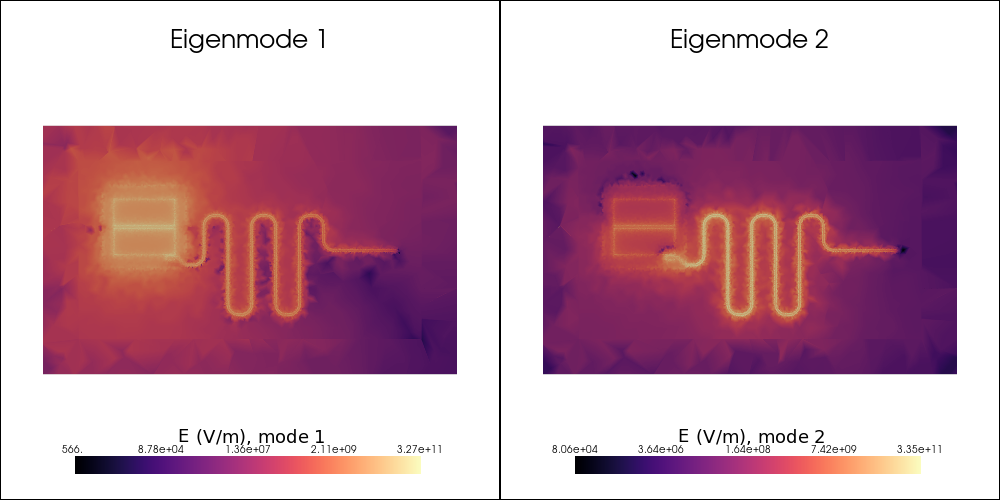

Image saved to ‘E:\x\qiskit_metal\289_Project\output\t3_eig\qtcad-fields.png’.


WindowsPath('E:/x/qiskit_metal/289_Project/output/t3_eig/qtcad-fields.png')

In [6]:
# --- QTCAD EIGENMODE SIMULATION ---
from qiskit_metal.toolbox_metal.parsing import parse_units

# 1. Define physical constants as pure numbers
inductance_val = 10e-9
gap_val = float(parse_units(qubit.options.pad_gap))
print(f"Using numeric values: Lj={inductance_val} H, Gap={gap_val} m")

# 2. Initialize Renderer
qtcad_renderer = QQTCADRenderer(
    design,
    options=dict(
        adaptive=True,
        output_dir=output_dir,
        geo_filepath=geo_filepath,
        mesh_filepath=mesh_filepath,
        mesh_scale=1e-3,
        adaptive_mesh_scale=1e-3,
        make_subdir=False,
        maxwell_emode=dict(
            num_modes=num_modes,
            tol_rel=0.05,
        ),
    ),
)

# 3. Render and Setup Junction
qtcad_renderer.render_design(
    open_pins=open_pins,
    skip_junctions=False,
    mesh_geoms=False,
    initial_mesh_h_min=mesh_h_min,
    initial_mesh_h_max=mesh_h_max,
)
qtcad_renderer.set_up_junction(transmon_label, inductance_val, gap_val)

# 4. Mesh and Solve
print("Meshing device...")
qtcad_renderer.gmsh.add_mesh(dim=3, intelli_mesh=False)
qtcad_renderer.export_mesh()
qtcad_renderer.export_parameters()

print("\n--- Running QTCAD Maxwell Eigenmode Simulation ---")
qtcad_renderer.run_qtcad("eigs")

# 5. Load Results
frequencies = qtcad_renderer.load_qtcad_maxwell_eigenmodes()
print("\nMaxwell Eigenmode Frequencies (GHz):")
print(frequencies)

qtcad_renderer.plot_eigenmodes(save=True)